In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cv2 as cv

#Impoting the image
img = cv.imread('heroine.jpg')

#Changing the image to gray scale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#Initialize SIFT detector
sift = cv.SIFT_create()

#Detecting key points of the image
kp = sift.detect(gray, None)

#Drawing the keypoints on the image
img = cv.drawKeypoints(gray, kp, img)

#DIsplay image with keypoints
cv.imshow('SIFT Keypoints', img)
cv.waitKey(0)
cv.imwrite('sift_keypoints.jpg', img)


True

In [3]:
import numpy as np

#Create a mask initaialise with zero
mask = np.zeros(gray.shape, dtype=np.uint8)

#Define ROI coordinates
x_start,y_start = 290,170
x_end,y_end = 456,368

#Set the ROI area in the mask to 255
mask[y_start:y_end, x_start:x_end] = 255

#Initialize SIFT detector
sift = cv.SIFT_create()

#Detect keypoints using mask
kp = sift.detect(gray,mask)

# Draw keypoints on the image
img_with_kp = cv.drawKeypoints(img, kp, None)

# Highlight the ROI with a rectangle (in red for visibility)
cv.rectangle(img_with_kp, (x_start, y_start), (x_end, y_end), (0, 0, 255), 2) 

# Display the image with keypoints and ROI
cv.imshow('SIFT Keypoints with ROI', img_with_kp)
cv.waitKey(0)

-1

######
 it computes 128-dimensional descriptor vectors for the SIFT keypoints detected earlier, encoding local image gradient patterns around each keypoint in a rotation- and scale-invariant way.

In [5]:
kp, des = sift.detectAndCompute(gray, mask)
if des is not None:
    print(f"Found {len(kp)} keypoints with descriptors shape: {des.shape}")
else:
    print("No keypoints or descriptors found—try enlarging ROI or reducing mask constraints.")

No keypoints or descriptors found—try enlarging ROI or reducing mask constraints.


In [2]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.7 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 3.2 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 3.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 3.2 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.3 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.4 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 3.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 3.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 3.5 MB/s eta 0:00:01
   -------------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 177 keypoints
Descriptors shape: (177, 128)


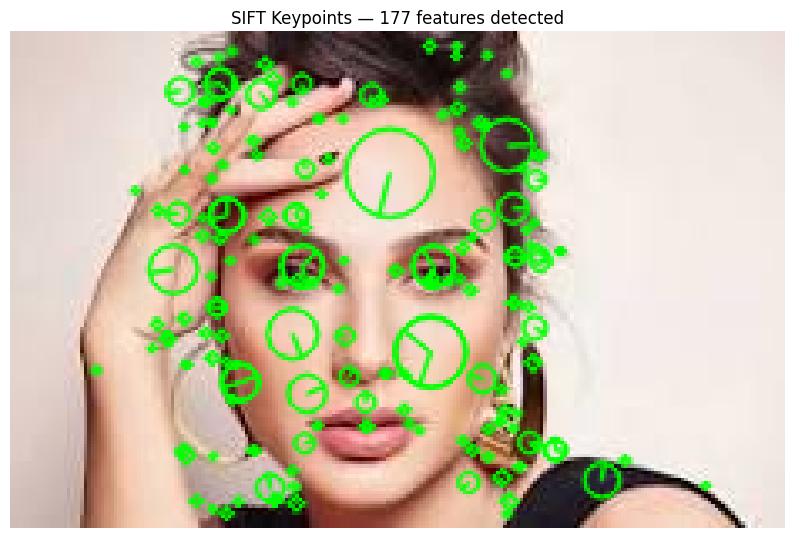

Image with keypoints saved as: sift_keypoints_heroine.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Load your image (change filename if needed)
# ────────────────────────────────────────────────
img_path = 'heroine.jpg'
img = cv2.imread(img_path)

if img is None:
    print(f"Error: Could not load image at '{img_path}'. Check the file path and name.")
    exit()

# Convert to grayscale (SIFT works on grayscale)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# Initialize SIFT detector

sift = cv2.SIFT_create(
    nfeatures=0,           # 0 = unlimited (default is 0 anyway)
    nOctaveLayers=3,
    contrastThreshold=0.04,
    edgeThreshold=10,
    sigma=1.6
)

# Detect keypoints and compute descriptors
kp, des = sift.detectAndCompute(gray, None)

if kp is None or len(kp) == 0:
    print("No keypoints were detected. The image might be too smooth/blurry — try a different image.")
    exit()

print(f"Found {len(kp)} keypoints")
if des is not None:
    print(f"Descriptors shape: {des.shape}")
else:
    print("Descriptors could not be computed (very unusual with SIFT)")

# ────────────────────────────────────────────────
# Draw keypoints on the original image
# ────────────────────────────────────────────────
# Rich keypoints = show orientation + scale as circles with lines
img_with_kp = cv2.drawKeypoints(
    img, 
    kp, 
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(0, 255, 0)   # green
)

# ────────────────────────────────────────────────
# Show the result — choose one or both methods
# ────────────────────────────────────────────────

# Option 1: Using matplotlib (recommended for Jupyter/notebooks — correct colors)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f'SIFT Keypoints — {len(kp)} features detected')
plt.axis('off')
plt.show()

# Option 2: Using OpenCV window (good for standalone .py scripts)
# cv2.imshow('SIFT Keypoints', img_with_kp)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# Save the result
output_path = 'sift_keypoints_heroine.jpg'
cv2.imwrite(output_path, img_with_kp)
print(f"Image with keypoints saved as: {output_path}")